In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("karaikal.csv")
df = df.dropna()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")
df.head()

,time,temperature,dewpoint,pressure,wind_u,wind_v,cloud_cover,humidity,rain_mm
0,2021-01-01 00:00:00,25.006378,21.004670,1010.6362,-3.620275,-5.611431,0.447605,78.490326,0.000000
1,2021-01-01 06:00:00,27.137115,20.595917,1013.3044,-4.586198,-5.499852,0.974360,67.477300,0.000000
2,2021-01-01 12:00:00,26.107025,21.898743,1010.6350,-3.636195,-5.447638,1.000001,77.662346,0.108626
3,2021-01-01 18:00:00,25.648956,21.057404,1012.3875,-2.965548,-6.047995,0.997626,75.792270,0.000000
4,2021-01-02 00:00:00,25.250275,21.408783,1010.4356,-1.692822,-5.638008,0.998517,79.300010,0.006484


In [3]:
feature_cols = [
    "temperature",
    "dewpoint",
    "pressure",
    "wind_u",
    "wind_v",
    "cloud_cover",
    "humidity"
]

target_col = "rain_mm"

X = df[feature_cols]
y = df[target_col]

In [4]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [5]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

In [6]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error
)

mse   = mean_squared_error(y_test, y_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
r2    = r2_score(y_test, y_pred)

print("\nXGBoost Evaluation Metrics")
print("R²     :", round(r2, 4))
print("MSE    :", round(mse, 4))
print("RMSE   :", round(rmse, 4))
print("MAE    :", round(mae, 4))
print("MedAE  :", round(medae, 4))


XGBoost Evaluation Metrics
R²     : 0.1244
MSE    : 0.1699
RMSE   : 0.4121
MAE    : 0.1056
MedAE  : 0.0214


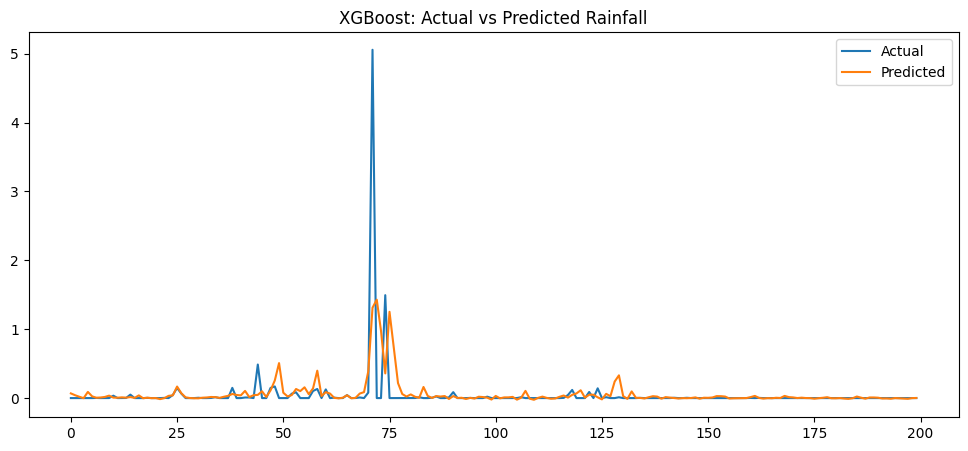

In [7]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("XGBoost: Actual vs Predicted Rainfall")
plt.show()

In [9]:
sample_input = pd.DataFrame([{
    "temperature": 30.2,
    "dewpoint": 24.8,
    "pressure": 1009.5,
    "wind_u": 1.5,
    "wind_v": -0.8,
    "cloud_cover": 0.65,
    "humidity": 78.3
}])

prediction = xgb_model.predict(sample_input)

prediction = np.clip(prediction, 0, None)

print("\nPredicted Rainfall for Given Input:")
print(f"{prediction[0]:.4f} mm")


Predicted Rainfall for Given Input:
0.0330 mm
